In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, cohen_kappa_score, matthews_corrcoef

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 25
BATCH_SIZE = 16
LR = 1e-4

TRAIN_PATH = r"F:\CV Project\LC25000\lung_colon_image_set\Train and Validation Set"
TEST_PATH  = r"F:\CV Project\LC25000\lung_colon_image_set\Test Set"

TARGET_CLASSES = ['colon_aca', 'colon_n']
K = 5

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [8]:
class FilteredImageFolder(Dataset):
    def __init__(self, root_dir, classes, transform=None):
        self.dataset = datasets.ImageFolder(root=root_dir)
        self.transform = transform
        
        self.classes = sorted(classes)
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = []

        for path, label in self.dataset.samples:
            class_name = self.dataset.classes[label]
            if class_name in self.classes:
                self.samples.append((path, self.class_to_idx[class_name]))

        print(f"Loaded {len(self.samples)} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        try:
            image = Image.open(path).convert("RGB")
        except:
            image = Image.new("RGB", (224,224))

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
full_dataset = FilteredImageFolder(TRAIN_PATH, TARGET_CLASSES, transform=train_transform)

Loaded 9000 samples


In [10]:
def get_model():
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)

    for param in model.features[:2].parameters():
        param.requires_grad = False

    for param in model.features[2:].parameters():
        param.requires_grad = True

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 2)
    )

    return model.to(device)

In [11]:
def train_model(model, train_loader, val_loader):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.3
    )

    best_loss = float('inf')
    patience = 5
    counter = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss, correct = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = correct / len(train_loader.dataset)

        model.eval()
        val_loss, val_correct = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | Val Loss={val_loss:.4f}, Acc={val_acc:.4f}")

        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping")
            break

In [12]:
kf = KFold(n_splits=K, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(full_dataset)):
    print(f"\n🔥 Fold {fold+1}/{K}")

    train_subset = Subset(full_dataset, train_idx)
    val_subset   = Subset(full_dataset, val_idx)

    val_subset.dataset.transform = val_transform

    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

    model = get_model()
    train_model(model, train_loader, val_loader)

    # Validation Accuracy
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(1)
            correct += (preds == labels).sum().item()

    acc = correct / len(val_subset)
    fold_results.append(acc)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")


🔥 Fold 1/5
Epoch 1: Train Loss=0.1788, Acc=0.9786 | Val Loss=0.1204, Acc=1.0000
Epoch 2: Train Loss=0.1248, Acc=0.9990 | Val Loss=0.1188, Acc=1.0000
Epoch 3: Train Loss=0.1230, Acc=0.9993 | Val Loss=0.1183, Acc=1.0000
Epoch 4: Train Loss=0.1219, Acc=0.9996 | Val Loss=0.1178, Acc=1.0000
Epoch 5: Train Loss=0.1197, Acc=1.0000 | Val Loss=0.1178, Acc=1.0000
Epoch 6: Train Loss=0.1195, Acc=1.0000 | Val Loss=0.1175, Acc=1.0000
Epoch 7: Train Loss=0.1192, Acc=1.0000 | Val Loss=0.1176, Acc=1.0000
Epoch 8: Train Loss=0.1191, Acc=1.0000 | Val Loss=0.1174, Acc=1.0000
Epoch 9: Train Loss=0.1192, Acc=1.0000 | Val Loss=0.1174, Acc=1.0000
Epoch 10: Train Loss=0.1194, Acc=1.0000 | Val Loss=0.1174, Acc=1.0000
Epoch 11: Train Loss=0.1191, Acc=1.0000 | Val Loss=0.1173, Acc=1.0000
Epoch 12: Train Loss=0.1192, Acc=0.9999 | Val Loss=0.1173, Acc=1.0000
Epoch 13: Train Loss=0.1187, Acc=1.0000 | Val Loss=0.1172, Acc=1.0000
Epoch 14: Train Loss=0.1186, Acc=1.0000 | Val Loss=0.1171, Acc=1.0000
Epoch 15: Train L

In [13]:
print("\nK-Fold Results:")
for i, acc in enumerate(fold_results):
    print(f"Fold {i+1}: {acc:.4f}")

print("Average:", np.mean(fold_results))
print("Std Dev:", np.std(fold_results))


K-Fold Results:
Fold 1: 1.0000
Fold 2: 1.0000
Fold 3: 1.0000
Fold 4: 1.0000
Fold 5: 1.0000
Average: 1.0
Std Dev: 0.0


In [14]:
test_dataset = FilteredImageFolder(TEST_PATH, TARGET_CLASSES, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

Loaded 1000 samples


C:\Users\Bramha\AppData\Local\Temp\ipykernel_8156\3238686058.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


In [15]:
class_names = ['Colon_Adenocarcinoma', 'Colon_Normal']

print(classification_report(y_true, y_pred, target_names=class_names))

print("ROC-AUC:", roc_auc_score(y_true, y_pred))
print("Kappa:", cohen_kappa_score(y_true, y_pred))
print("MCC:", matthews_corrcoef(y_true, y_pred))

                      precision    recall  f1-score   support

Colon_Adenocarcinoma       1.00      1.00      1.00       500
        Colon_Normal       1.00      1.00      1.00       500

            accuracy                           1.00      1000
           macro avg       1.00      1.00      1.00      1000
        weighted avg       1.00      1.00      1.00      1000

ROC-AUC: 1.0
Kappa: 1.0
MCC: 1.0


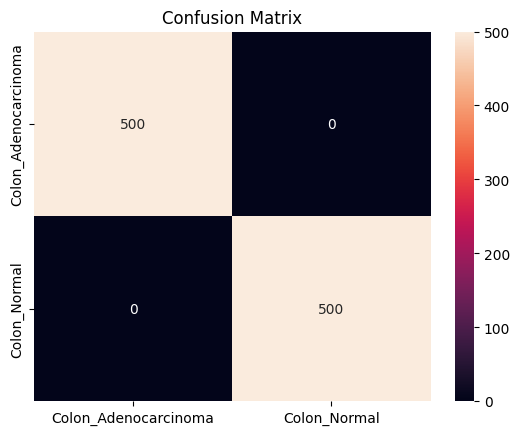

In [16]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.show()